In [1]:
import sys, os
sys.path.insert(0, '../utils')

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from utils import load_neurons_table, load_synapses_position_transformed
from connectome_types import CONNECTOME_SYN_TABLE_PATH
from neuron_custom_features import calc_spines_features
from spines_utils import filter_valid_neuron_w_spines, get_incoming_neurons_sets
from plot_utils import plot_skeleton_continuous, ex_color
from figures_utils import plot_clf_type_triple_binned, add_panel_label, plot_branch_from_image
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm
from connectome_types import DATA_BASE_PATH, IMAGES_BASE_PATH, NETWORK_NAME
import matplotlib.tri as mtri
from standard_transform import minnie_ds
from mesh_utils import load_full_mesh, extract_dendrite_mesh_via_sk, plot_branch
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
from sk_load_utils import load_clean_sk, load_col_skeleton_only

neurons_df = load_neurons_table(use_column_manual_ct=True)
syn_df = load_synapses_position_transformed(base_syn_table_path=CONNECTOME_SYN_TABLE_PATH)
df, syn_with_tags = calc_spines_features(neurons_df, syn_df)
df, filtered_syn_mat, filtered_bin_mat, filtered_mapping, filtered_reverse_mapping, ex_neurons, inh_neurons = filter_valid_neuron_w_spines(df)

connectome neurons table:  1351
valid neurons w position: 1351
spine table incoming size (4567647, 4)
spine table outgoing size (819832, 4)
neurons: 1351
synapses with tags: 145356


100%|██████████| 1351/1351 [00:18<00:00, 71.24it/s]


Filtering neurons with valid spine data...
Remaining neurons after filtering: 1298
fixing networks
Filtering: Reducing matrix from 1351 to 1298 neurons.


In [3]:
spiny_neuron = 864691136618553563
aspiny_neuron =  864691135214643256

spiny_sk = load_col_skeleton_only(spiny_neuron, reset_axon=True, old=True)
aspiny_sk = load_col_skeleton_only(aspiny_neuron, reset_axon=True, old=True)

spiny_sk_clean = load_clean_sk(spiny_neuron)
aspiny_sk_clean = load_clean_sk(aspiny_neuron)

spiny_neuron_df = df[df.root_id == spiny_neuron]
aspiny_neuron_df = df[df.root_id == aspiny_neuron]

print(f"Spiny neuron cell type: {spiny_neuron_df.cell_type.iloc[0]} spine density: {spiny_neuron_df.ds_spine_density.iloc[0]:.2f} spines per micron")
print(f"Aspiny neuron cell type: {aspiny_neuron_df.cell_type.iloc[0]} spine density: {aspiny_neuron_df.ds_spine_density.iloc[0]:.2f} spines per micron")

Spiny neuron cell type: 4P spine density: 1.20 spines per micron
Aspiny neuron cell type: 6P-IT spine density: 0.27 spines per micron


In [4]:
neuron_clf_type = df[['root_id', 'clf_type']].set_index('root_id').to_dict(orient='index')
node_clf_type = {idx: neuron_clf_type[filtered_mapping[idx]]['clf_type'] for idx in filtered_mapping}

incoming_neurons_sets = get_incoming_neurons_sets(filtered_bin_mat)
ex_incoming_neurons_sets = []
inh_incoming_neurons_sets = []

for neuron_set in incoming_neurons_sets:
    ex_set = {n_id for n_id in neuron_set if node_clf_type.get(n_id) == 'E'}
    inh_set = {n_id for n_id in neuron_set if node_clf_type.get(n_id) == 'I'}

    ex_incoming_neurons_sets.append(ex_set)
    inh_incoming_neurons_sets.append(inh_set)

In [5]:
def get_df_partners(neuron_id):
    neuron_ex_friends_nodes = ex_incoming_neurons_sets[filtered_reverse_mapping[neuron_id]]
    neuron_inh_friends_nodes = inh_incoming_neurons_sets[filtered_reverse_mapping[neuron_id]]

    neuron_ex_friends = {filtered_mapping[idx] for idx in neuron_ex_friends_nodes}
    neuron_inh_friends = {filtered_mapping[idx] for idx in neuron_inh_friends_nodes}

    neuron_ex_friends_df = df[df.root_id.isin(neuron_ex_friends)].copy()
    neuron_inh_friends_df = df[df.root_id.isin(neuron_inh_friends)].copy()

    print(df[df.root_id == neuron_id][['num_of_ex_incoming_neurons', 'num_of_inh_incoming_neurons']])
    print(len(neuron_ex_friends), len(neuron_inh_friends))

    return neuron_ex_friends_df, neuron_inh_friends_df

In [6]:
spiny_ex_partners, spiny_inh_partners = get_df_partners(spiny_neuron)
aspiny_ex_partners, aspiny_inh_partners = get_df_partners(aspiny_neuron)

ex_intersection = set(spiny_ex_partners.root_id).intersection(set(aspiny_ex_partners.root_id))
inh_intersection = set(spiny_inh_partners.root_id).intersection(set(aspiny_inh_partners.root_id))
print(f'Number of shared excitatory partners: {len(ex_intersection)}')
print(f'Number of shared inhibitory partners: {len(inh_intersection)}')

     num_of_ex_incoming_neurons  num_of_inh_incoming_neurons
365                          30                           42
30 42
      num_of_ex_incoming_neurons  num_of_inh_incoming_neurons
1025                          13                           17
13 17
Number of shared excitatory partners: 0
Number of shared inhibitory partners: 2


In [7]:
# ── Meshes or skeletons? ──────────────────────────────────────────────────────
# The cell is drawn either from its segmented surface mesh or from its skeleton.
# Skeletons are the default: all 1,351 of them ship in data/, they load in
# seconds, and the panel reads correctly from them.
#
# Set USE_MESHES = True to reproduce the beautiful panels as they appear in the
# paper. That needs data/micro_column_network/meshes/ (~1.4 GB — on Zenodo, or
# `python download_data_cave.py --steps meshes`) and is markedly slower to draw.
#
# The zoomed dendrite insets come from the pre-rendered images in images/, which
# ship with this repository, so they look the same whatever this flag says — see
# the README. Neither download route can rebuild them.
USE_MESHES = False

In [8]:
if USE_MESHES:
    mesh_path = f"{DATA_BASE_PATH}/{NETWORK_NAME}/meshes"
    spiny_mesh_full = load_full_mesh(spiny_neuron, mesh_path)
    aspiny_mesh_full = load_full_mesh(aspiny_neuron, mesh_path)
else:
    spiny_mesh_full = aspiny_mesh_full = None
    spiny_mesh_dendrite = aspiny_mesh_dendrite = None
    spiny_mesh_triang = aspiny_mesh_triang = None

In [9]:
if USE_MESHES:
    spiny_mesh_dendrite = extract_dendrite_mesh_via_sk(spiny_sk_clean, spiny_mesh_full)
    vertices_um = minnie_ds.transform_nm.apply(spiny_mesh_dendrite.vertices)
    spiny_mesh_triang = mtri.Triangulation(vertices_um[:, 0], vertices_um[:, 1], spiny_mesh_dendrite.faces)

    aspiny_mesh_dendrite = extract_dendrite_mesh_via_sk(aspiny_sk_clean, aspiny_mesh_full)
    avertices_um = minnie_ds.transform_nm.apply(aspiny_mesh_dendrite.vertices)
    aspiny_mesh_triang = mtri.Triangulation(avertices_um[:, 0], avertices_um[:, 1], aspiny_mesh_dendrite.faces)

In [10]:
plt.rcParams['font.family'] = 'Arial'

plt.rcParams['font.size'] = 13
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

main_x_feature = 'ds_spine_density'
x_label = 'Density of spinous synapses\n(syn/μm)'

alpha = 0.8
plus_inner_size = 60
minus_inner_size = 60
line_width = 0.75

spiny_color =  '#7C3AED' 
aspiny_color = '#059669'
mesh_lw = 0.1

In [11]:
branches_fixed_images_dir = f'{IMAGES_BASE_PATH}/fig2_branches'
branches_images = []
for img_path in os.listdir(branches_fixed_images_dir):
    img = plt.imread(os.path.join(branches_fixed_images_dir, img_path))
    branches_images.append(img)

C:\Users\dean\AppData\Local\Temp\ipykernel_2572\263532489.py:103: MatplotlibDeprecationWarning: Since Matplotlib 3.10 indicate_inset_[zoom] returns a single InsetIndicator artist with a rectangle property and a connectors property.  From 3.12 it will no longer be possible to unpack the return value into two elements.
  rect, connectors = ax_main.indicate_inset_zoom(


[0.125, 0.375, 0.625, 0.875, 1.125, 1.375]
Sum of bin counts for E→E: 1139
Sum of bin counts for E→E: 1139
Sum of bin counts for E→E: 1139


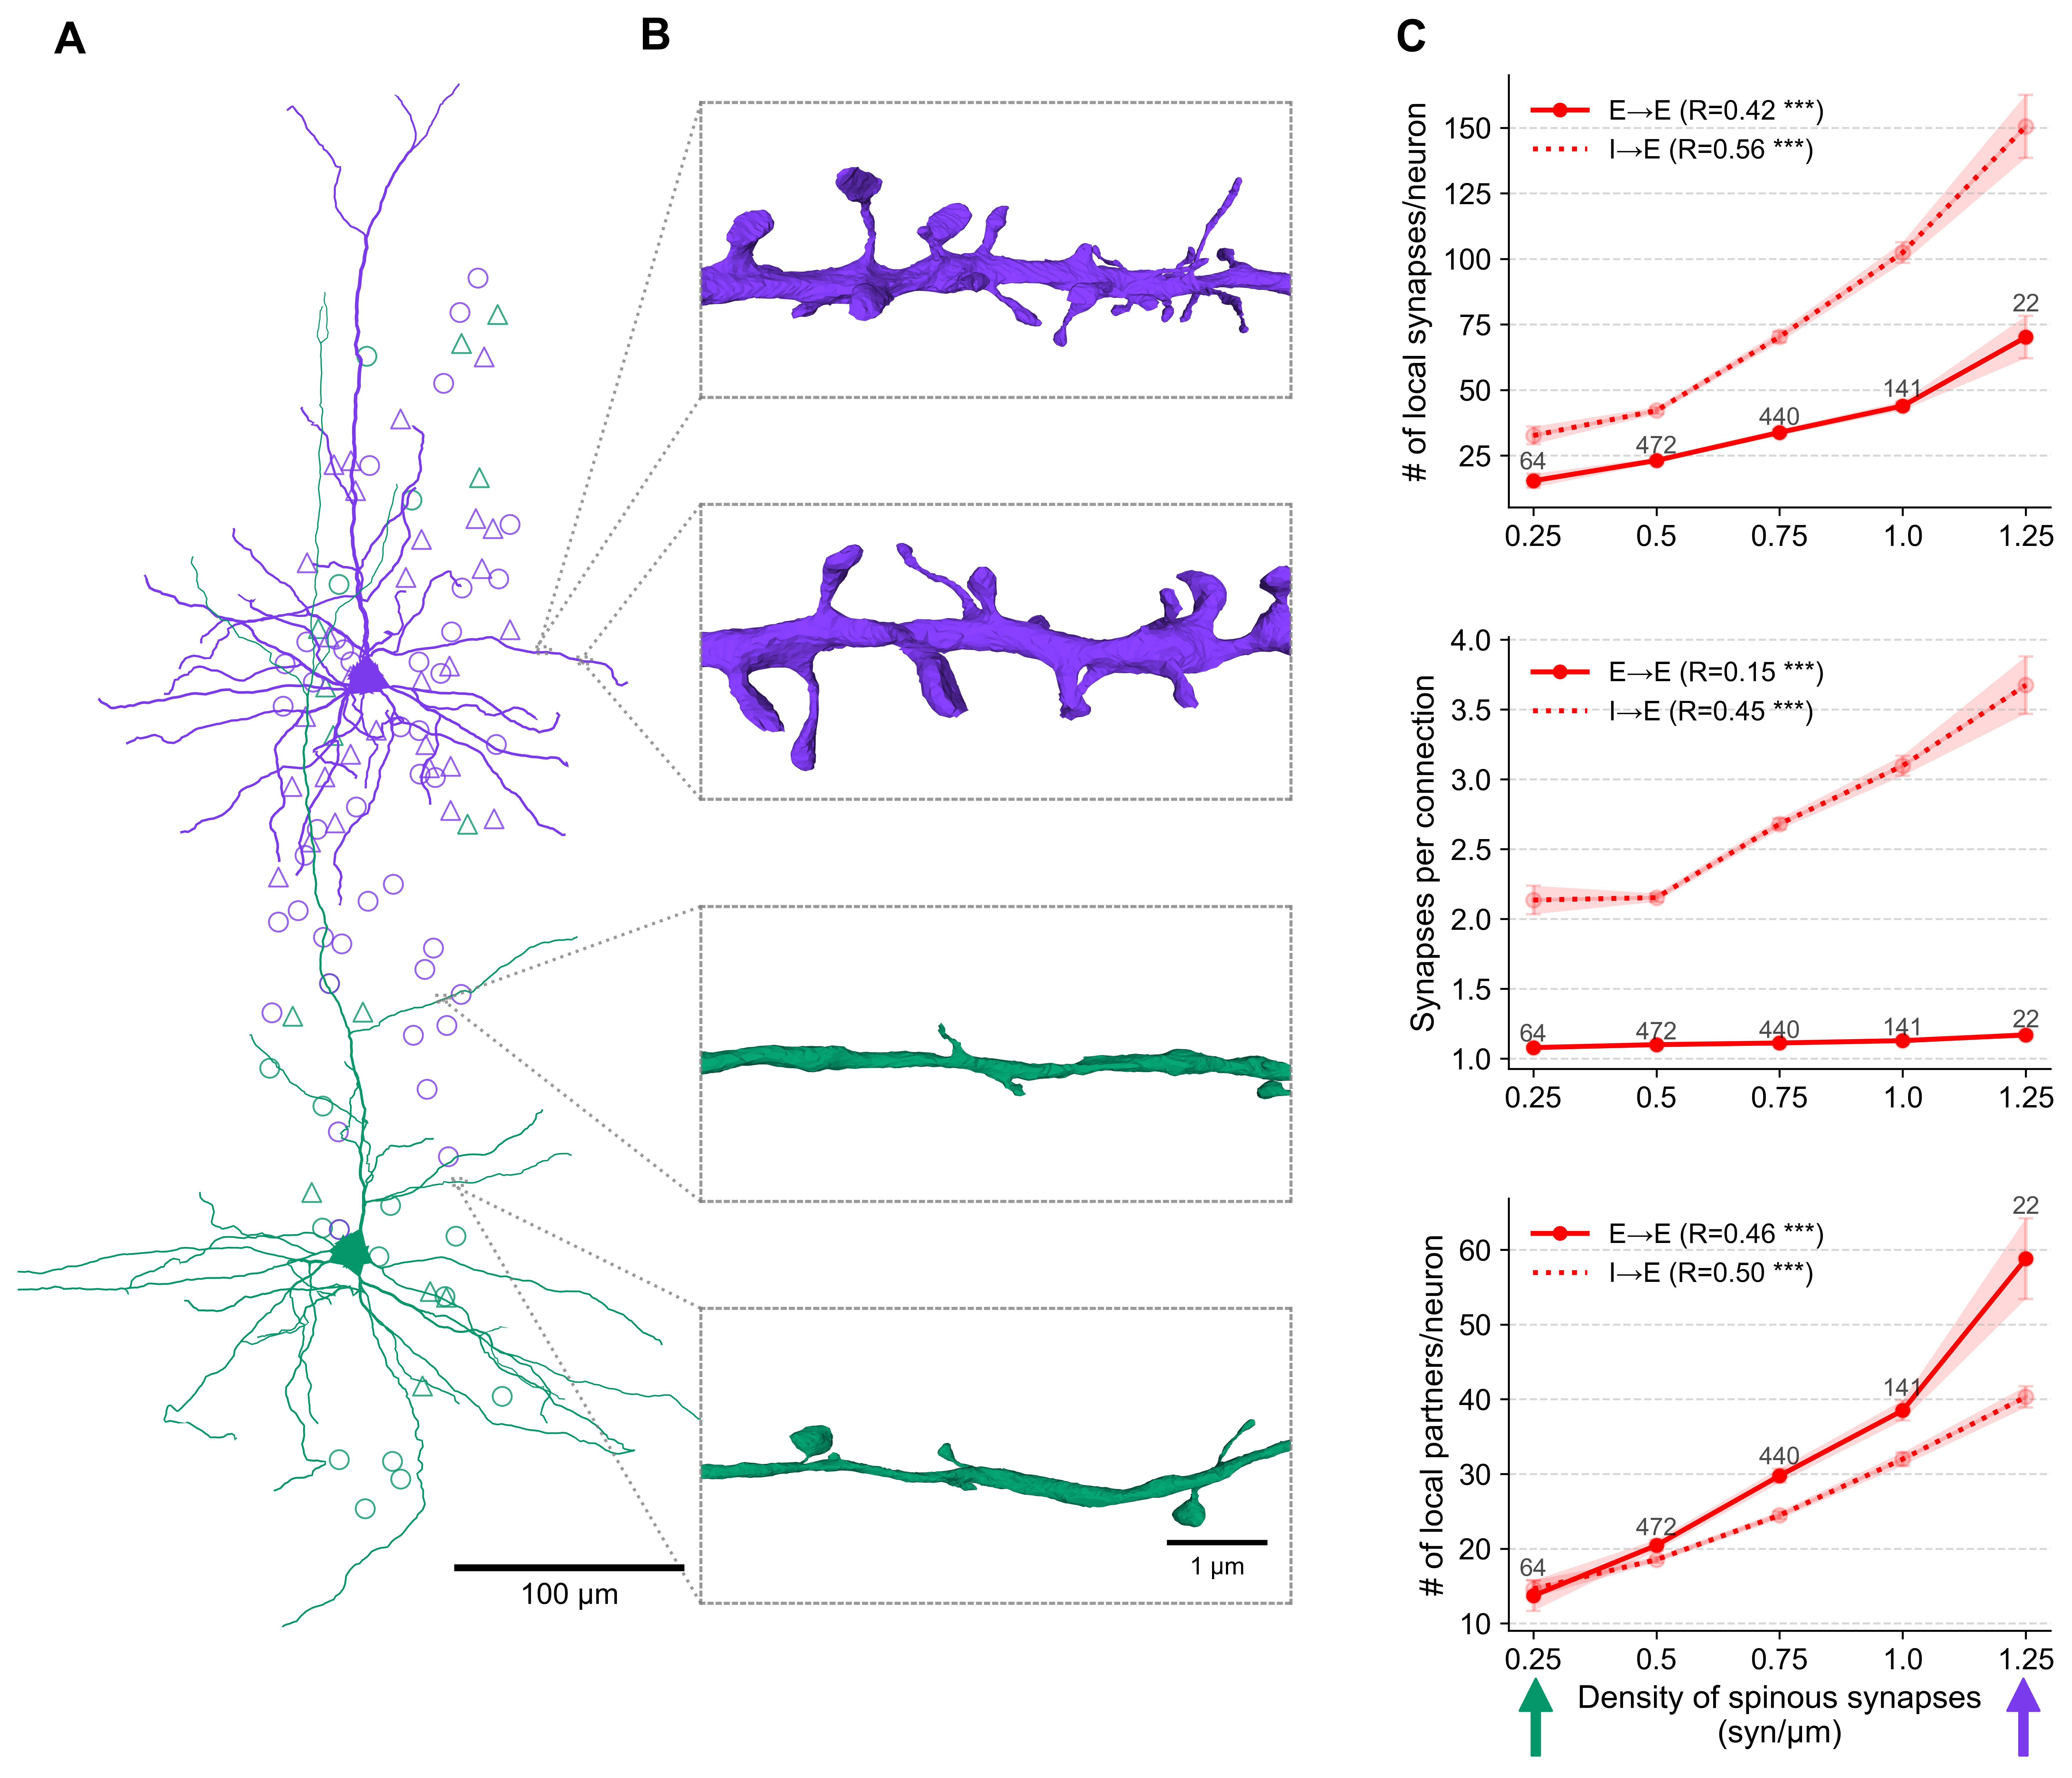

In [12]:
fig = plt.figure(figsize=(12.5, 11), dpi=600)
fig.subplots_adjust(left=0.05, right=0.97, bottom=0.08, top=0.88)

gs_master = fig.add_gridspec(1, 2, width_ratios=[2.35, 1], wspace=0.24)
gs_left = gs_master[0].subgridspec(4, 2, width_ratios=[1.1, 0.95], wspace=0.0, hspace=0.15)
gs_right = gs_master[1].subgridspec(3, 1, hspace=0.3)

# ==========================================
# PLOT LEFT SIDE 
# ==========================================
ax_main = fig.add_subplot(gs_left[:, 0])   # Column A: Main Neuron
ax_b1 = fig.add_subplot(gs_left[0, 1])     # Column B: Branches
ax_b2 = fig.add_subplot(gs_left[1, 1])     
ax_b3 = fig.add_subplot(gs_left[2, 1])     
ax_b4 = fig.add_subplot(gs_left[3, 1])
branch_axes = [ax_b1, ax_b2, ax_b3, ax_b4]

# Aspiny
ax_main.scatter(aspiny_ex_partners.pt_position_xt, aspiny_ex_partners.pt_position_yt, 
           s=plus_inner_size, alpha=alpha, facecolors='none',
           edgecolors=aspiny_color, marker='^', linewidths=line_width)

ax_main.scatter(aspiny_inh_partners.pt_position_xt, aspiny_inh_partners.pt_position_yt, 
           s=minus_inner_size, alpha=alpha, facecolors='none',
           edgecolors=aspiny_color, marker='o', linewidths=line_width)

# Spiny
ax_main.scatter(spiny_ex_partners.pt_position_xt, spiny_ex_partners.pt_position_yt, 
           s=plus_inner_size, alpha=alpha, facecolors='none',
           edgecolors=spiny_color, marker='^', linewidths=line_width)

ax_main.scatter(spiny_inh_partners.pt_position_xt, spiny_inh_partners.pt_position_yt, 
           s=minus_inner_size, alpha=alpha, facecolors='none',
           edgecolors=spiny_color, marker='o', linewidths=line_width)

if USE_MESHES:
    # plot_mesh_shaded(ax_main, spiny_mesh_dendrite, minnie_ds.transform_nm, color=mcolors.to_rgb(spiny_color))
    # plot_mesh_shaded(ax_main, aspiny_mesh_dendrite, minnie_ds.transform_nm, color=mcolors.to_rgb(aspiny_color))
    ax_main.triplot(spiny_mesh_triang, color=spiny_color, alpha=1, lw=mesh_lw)
    ax_main.triplot(aspiny_mesh_triang, color=aspiny_color, alpha=1, lw=mesh_lw)
else:
    plot_skeleton_continuous(ax=ax_main, sk=spiny_sk, lw=1.4, alpha=1, color=spiny_color, ignore_vertex_zero=False)
    plot_skeleton_continuous(ax=ax_main, sk=aspiny_sk, lw=1.4, alpha=1, color=aspiny_color, ignore_vertex_zero=False)

# Main Plot Formatting
ax_main.set_xlim(500, 800) 
ax_main.set_ylim(700, 20) # Note: Y-axis is inverted here!

for spine in ax_main.spines.values():
    spine.set_visible(False)

ax_main.set_xlabel('')
ax_main.set_ylabel('')

fontprops_main = fm.FontProperties(size=12)
scalebar_main = AnchoredSizeBar(transform=ax_main.transData, size=100, label='100 µm', 
                                loc='lower right', pad=0.5, color='black', frameon=False, sep=5,
                                size_vertical=2, fontproperties=fontprops_main)
ax_main.add_artist(scalebar_main)
ax_main.tick_params(left=False, right=False, labelleft=False, labelbottom=False, bottom=False)

# The 4 Branches
if USE_MESHES and len(os.listdir(branches_fixed_images_dir)) == 0:
    plot_branch(xlim=(726,736), ylim=(269,274), mesh=spiny_mesh_dendrite, mesh_triang=spiny_mesh_triang, mesh_color=spiny_color, plot_shaded_mesh=True, ax=ax_b1, add_scale_bar=False)
    plot_branch(xlim=(744,754), ylim=(273,278), mesh=spiny_mesh_dendrite, mesh_triang=spiny_mesh_triang, mesh_color=spiny_color, plot_shaded_mesh=True, ax=ax_b2, add_scale_bar=False)
    plot_branch(xlim=(682, 692), ylim=(421.5,426.5), mesh_triang=aspiny_mesh_triang, mesh=aspiny_mesh_dendrite, mesh_color=aspiny_color, plot_shaded_mesh=True, ax=ax_b3, add_scale_bar=False)
    plot_branch(xlim=(689, 699), ylim=(502,502+5), mesh_triang=aspiny_mesh_triang, mesh=aspiny_mesh_dendrite, mesh_color=aspiny_color, plot_shaded_mesh=True, ax=ax_b4, add_scale_bar=False)
else:
    plot_branch_from_image(ax_b1, branch_idx=0, branches_images=branches_images, original_xlim=(726, 736), original_ylim=(269, 274), move_lower=0.5)
    plot_branch_from_image(ax_b2, branch_idx=1, branches_images=branches_images, original_xlim=(744, 754), original_ylim=(273, 278))
    plot_branch_from_image(ax_b3, branch_idx=2, branches_images=branches_images, original_xlim=(682, 692), original_ylim=(421.5, 426.5))
    plot_branch_from_image(ax_b4, branch_idx=3, branches_images=branches_images, original_xlim=(689, 699), original_ylim=(502, 507))

if len(os.listdir(branches_fixed_images_dir)) == 0:
    scale_vertical = 0.055  
    fontprops_main = fm.FontProperties(size=12)
else:
    scale_vertical = 0.03
    fontprops_main = fm.FontProperties(size=10)

pos_bot = ax_b4.get_position()
scalebar_bottom = AnchoredSizeBar(transform=ax_b4.transData, size=1, label='1 µm', sep=5,
                               loc='lower right', pad=0.5, borderpad=0.5,
                               color='black', frameon=False,
                               size_vertical=scale_vertical, fontproperties=fontprops_main)
                            #    bbox_to_anchor=(0.9, pos_bot.y0 - 0.01))
ax_b4.add_artist(scalebar_bottom)

# Draw Zoom Connection Lines
zoomed_color = 'grey'
zoomed_alpha = 0.8
zoomed_lw = 1.25
zoomed_style = ':'

for ax_branch in branch_axes:
    for spine in ax_branch.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(zoomed_lw)
        spine.set_color(zoomed_color)
        spine.set_linestyle(zoomed_style)
        spine.set_alpha(zoomed_alpha)

    rect, connectors = ax_main.indicate_inset_zoom(
        ax_branch,
        edgecolor=zoomed_color,
        linewidth=zoomed_lw,
        linestyle=zoomed_style,
        alpha=zoomed_alpha
    )

    rect.set_visible(True)
    rect.set_linestyle(zoomed_style)
    rect.set_linewidth(zoomed_lw)
    rect.set_alpha(zoomed_alpha)
    rect.set_edgecolor(zoomed_color)
    rect.set_facecolor('none')   # transparent fill

    connectors[0].set_visible(True)   # lower connector
    connectors[1].set_visible(True)   # upper connector
    connectors[2].set_visible(False)
    connectors[3].set_visible(False)

# ==========================================
# PLOT RIGHT SIDE (Panel C only — no Panel D)
# ==========================================
axes = np.empty((3, 1), dtype=object)
for i in range(3):
    axes[i, 0] = fig.add_subplot(gs_right[i, 0])

plot_clf_type_triple_binned(
    df=ex_neurons, 
    names=['E→E', 'I→E'], 
    colors=[ex_color, ex_color],
    x_axis=main_x_feature, 
    x_label=x_label, 
    ax_list=axes[:, 0],
    main_x_feature=main_x_feature,
    bin_amount_text_size=10,
)

add_panel_label(ax_main, 'A', xy=(0.1, 1.0105))
add_panel_label(ax_b1, 'B', xy=(-0.05, 1.15))
add_panel_label(axes[0, 0], 'C', xy=(-0.15, 1.035))

## Arrows
ax_target = axes[2, 0]
arrow_props_common = {'arrowstyle': 'simple,head_width=1.0,head_length=1.0,tail_width=0.25', 'clip_on': False}
ax_target.annotate('', 
                    xy=(0.05, -0.1), xycoords='axes fraction', 
                    xytext=(0.05, -0.3), textcoords='axes fraction',
                    arrowprops={'color': aspiny_color, **arrow_props_common})
ax_target.annotate('', 
                    xy=(0.95, -0.1), xycoords='axes fraction', 
                    xytext=(0.95, -0.3), textcoords='axes fraction',
                    arrowprops={'color': spiny_color, **arrow_props_common})

plt.savefig('fig_2.png', transparent=False, bbox_inches='tight', pad_inches=0)

plt.show()